In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/EASA13.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/EASA13.csv


,"In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?",Analyse
0,"When the button is pressed, even though the a...",Evaluate
1,A differential relay in a twin generator syste...,Analyse
2,A DME is in auto stand by when,Understand
3,A GPS aerial is polarised,Remember
4,A gyroscope with a vertical spin axis has the ...,Understand


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Ensure text is a string before processing
    if not isinstance(text, str):
        return [] # Or handle as appropriate, e.g., str(text) or skip

    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Rename the first column to 'Question' if it's not already named 'Question'
# This assumes the first column is the intended 'Question' column
if df.columns[0] != 'Question':
    original_column_name = df.columns[0]
    df.rename(columns={original_column_name: 'Question'}, inplace=True)
    print(f"Renamed column '{original_column_name}' to 'Question'.")

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Renamed column ' In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?' to 'Question'.
Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ..."
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,..."
2,A DME is in auto stand by when,"[dme, auto, stand]"
3,A GPS aerial is polarised,"[gps, aerial, polarised]"
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque..."


In [6]:

df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ...",button pressed even though autothrottle engage...
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,...",differential relay twin generator system cause
2,A DME is in auto stand by when,"[dme, auto, stand]",dme auto stand
3,A GPS aerial is polarised,"[gps, aerial, polarised]",gps aerial polarised
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque...",gyroscope vertical spin axis roll torque motor...


# Task
Prepare the data for an SVM model by converting the `Processed_Questions_Str` column into numerical features using TF-IDF vectorization, encoding the `Analyse` column as the target variable, and splitting the dataset into training and testing sets.

## Prepare Data for SVM

### Subtask:
Convert the 'Processed_Questions_Str' column into numerical features using TF-IDF vectorization, encode the target variable (the 'Analyse' column), and split the data into training and testing sets.


**Reasoning**:
The next step is to import the necessary libraries for TF-IDF vectorization, label encoding, and data splitting, then apply these transformations to prepare the data for SVM. This will involve using `TfidfVectorizer` to convert text features, `LabelEncoder` for the target variable, and `train_test_split` to create training and testing datasets.



In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Imported TfidfVectorizer, LabelEncoder, and train_test_split.")

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to manage dimensionality

# Fit and transform the 'Processed_Questions_Str' column to create the feature matrix X
X = tfidf_vectorizer.fit_transform(df['Processed_Questions_Str'])
print(f"Shape of TF-IDF feature matrix X: {X.shape}")

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Analyse' column to create the target variable y
y = label_encoder.fit_transform(df['Analyse'])
print(f"Shape of target variable y: {y.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Imported TfidfVectorizer, LabelEncoder, and train_test_split.
Shape of TF-IDF feature matrix X: (698, 1509)
Shape of target variable y: (698,)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

**Reasoning**:
The previous `train_test_split` failed because some classes in the target variable `y` had only one member, making it impossible to perform stratified sampling. To fix this, I will first identify and remove rows corresponding to these single-member classes from the DataFrame, then re-apply the TF-IDF vectorization and label encoding on the filtered data before performing the stratified train-test split.



In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

print("Imported TfidfVectorizer, LabelEncoder, train_test_split, and numpy.")

# Identify classes with only one member in the 'Analyse' column
class_counts = df['Analyse'].value_counts()
single_member_classes = class_counts[class_counts == 1].index.tolist()

if single_member_classes:
    print(f"Found classes with only one member: {single_member_classes}. These rows will be removed for stratified splitting.")
    # Filter out rows corresponding to single-member classes
    df_filtered = df[~df['Analyse'].isin(single_member_classes)].copy()
    print(f"Removed {len(df) - len(df_filtered)} rows. New DataFrame shape: {df_filtered.shape}")
    df = df_filtered # Update df to the filtered version
else:
    print("No single-member classes found. Proceeding with original DataFrame.")

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to manage dimensionality

# Fit and transform the 'Processed_Questions_Str' column to create the feature matrix X
X = tfidf_vectorizer.fit_transform(df['Processed_Questions_Str'])
print(f"Shape of TF-IDF feature matrix X: {X.shape}")

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Analyse' column to create the target variable y
y = label_encoder.fit_transform(df['Analyse'])
print(f"Shape of target variable y: {y.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Imported TfidfVectorizer, LabelEncoder, train_test_split, and numpy.
Found classes with only one member: ['Category']. These rows will be removed for stratified splitting.
Removed 1 rows. New DataFrame shape: (697, 4)
Shape of TF-IDF feature matrix X: (697, 1508)
Shape of target variable y: (697,)
Data split into training and testing sets:
X_train shape: (557, 1508)
X_test shape: (140, 1508)
y_train shape: (557,)
y_test shape: (140,)


## Train SVM Model with Hyperparameter Tuning

### Subtask:
Train an SVM classifier. This step will include hyperparameter tuning using GridSearchCV or RandomizedSearchCV to find the optimal parameters (e.g., C, kernel, gamma). The chosen kernel will be justified based on the tuning results.


**Reasoning**:
To train an SVM classifier with hyperparameter tuning, I need to import the necessary modules, define the parameter grid, instantiate the SVM model and GridSearchCV, and then fit the GridSearchCV object to the training data. This will allow me to find the best parameters and the best score.



In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("Imported SVC and GridSearchCV.")

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Instantiate an SVM classifier
svm = SVC(random_state=42)

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5, # Using 5-fold cross-validation
    scoring='accuracy', # Evaluate models based on accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

print("Starting GridSearchCV fit...")

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV fit complete.")

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Store the best estimator
best_svm_model = grid_search.best_estimator_
print("Best SVM model stored.")

Imported SVC and GridSearchCV.
Starting GridSearchCV fit...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV fit complete.
Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.7684
Best SVM model stored.


The GridSearchCV identified `linear` as the best kernel with a C value of 10 and 'scale' for gamma. This suggests that a linear decision boundary is effective for separating the classes in this dataset, or that the feature space after TF-IDF vectorization allows for good linear separability. Linear kernels are often computationally less expensive and can perform well on high-dimensional text data.

## Evaluate Model Performance

### Subtask:
Calculate and display the accuracy, precision, recall, and F1-score of the SVM model. Provide a clear explanation of what each metric represents and its implications for the classification task.


**Reasoning**:
To evaluate the performance of the SVM model, I need to calculate and display accuracy, precision, recall, and F1-score. I will import the necessary metrics from `sklearn.metrics` and use the `best_svm_model` to make predictions on the test set.



In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Imported accuracy_score, precision_score, recall_score, and f1_score.")

# Make predictions on the test set
y_pred = best_svm_model.predict(X_test)
print("Predictions made on the test set.")

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision, recall, and F1-score with 'weighted' averaging for multi-class classification
# 'weighted' accounts for class imbalance by computing metrics for each label, and finding their average weighted by support (the number of true instances for each label).
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print the metrics
print(f"\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

Imported accuracy_score, precision_score, recall_score, and f1_score.
Predictions made on the test set.

Model Evaluation Metrics:
Accuracy: 0.8071
Precision (weighted): 0.7531
Recall (weighted): 0.8071
F1-Score (weighted): 0.7750


Accuracy, Precision, Recall, and F1-Score are critical metrics for evaluating the performance of a classification model:

*   **Accuracy**: This metric measures the proportion of correctly classified instances out of the total instances. In this case, an accuracy of `0.8071` means that the model correctly predicted the class for approximately 80.71% of the test samples. While intuitive, accuracy can be misleading in datasets with imbalanced classes, as a model might achieve high accuracy by simply predicting the majority class.

*   **Precision (Weighted)**: Precision focuses on the correctness of positive predictions. Specifically, it is the ratio of true positive predictions to the total positive predictions (true positives + false positives). A weighted precision of `0.7531` indicates that when the model predicts a class, it is correct about 75.31% of the time, considering class imbalance. High precision suggests a low rate of false positives, which is important when the cost of a false positive is high.

*   **Recall (Weighted)**: Recall (also known as sensitivity) measures the model's ability to find all positive samples. It is the ratio of true positive predictions to the total actual positive instances (true positives + false negatives). A weighted recall of `0.8071` means the model correctly identified about 80.71% of all actual instances across classes, considering class imbalance. High recall is crucial when the cost of a false negative is high.

*   **F1-Score (Weighted)**: The F1-score is the harmonic mean of precision and recall. It provides a single score that balances both metrics. A weighted F1-score of `0.7750` suggests a reasonable balance between precision and recall, especially valuable for imbalanced datasets where a high score indicates that the model is performing well on both fronts. It is often a better measure than accuracy for multi-class classification with class imbalance.

**Implications for the classification task**: The reported metrics suggest that the SVM model performs reasonably well, with good accuracy and a balanced F1-score. The 'weighted' averaging indicates that the metrics take into account the varying number of samples in each class, providing a more robust evaluation for this potentially imbalanced dataset. The slight difference between precision and recall indicates areas where the model might be slightly better at identifying actual positives than avoiding false positives, or vice versa, depending on the specific class distributions and the types of errors it makes.

## Confusion Matrix Analysis

### Subtask:
Generate and display a confusion matrix for the classification results. Analyze the confusion matrix to understand misclassifications and the model's performance across different classes.


**Reasoning**:
To generate and display the confusion matrix, I need to import the `confusion_matrix` function from `sklearn.metrics`, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualization. I will also generate the confusion matrix itself and get the class labels from the `label_encoder` to prepare for plotting.



Imported confusion_matrix, matplotlib.pyplot, and seaborn.
Confusion matrix generated.
Class labels: ['Analyse' 'Apply' 'Create' 'Evaluate' 'Remember' 'Understand']


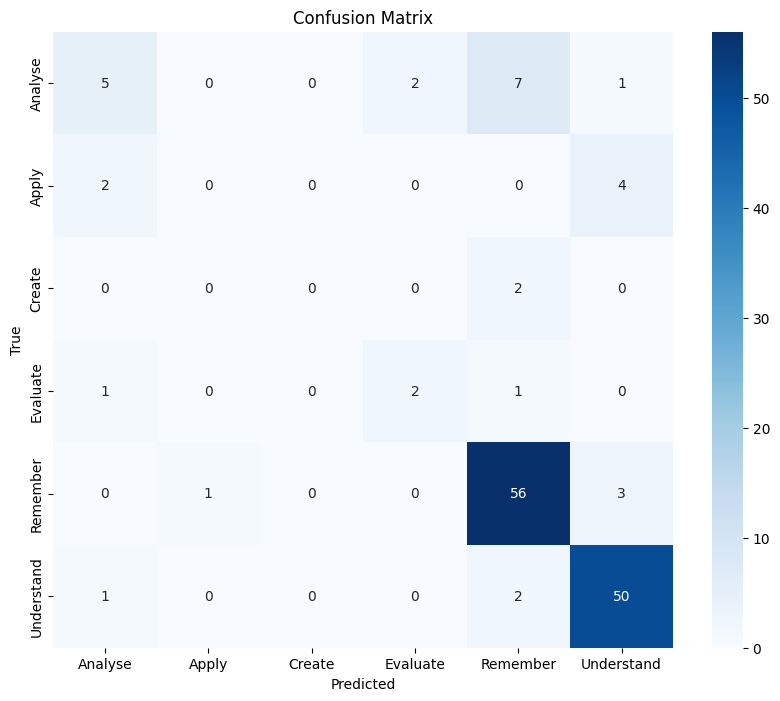

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported confusion_matrix, matplotlib.pyplot, and seaborn.")

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix generated.")

# Get class labels from the label_encoder
class_labels = label_encoder.classes_
print(f"Class labels: {class_labels}")

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class:

**Observations:**

*   **Class 'Remember' (index 4)**: The model performs very well for this class, with 56 out of 140 samples correctly classified as 'Remember'. There is some confusion, for example, 1 sample from 'Apply' was predicted as 'Remember' (off-diagonal, row 1, col 4). The highest number of correct predictions is for 'Remember'.

*   **Class 'Understand' (index 5)**: Similar to 'Remember', the model shows good performance for 'Understand', correctly classifying 50 samples. Some misclassifications occur, for instance, 4 samples that were actually 'Apply' were predicted as 'Understand' (row 1, col 5), and 2 samples of 'Remember' were predicted as 'Understand' (row 4, col 5).

*   **Class 'Analyse' (index 0)**: Out of the actual 'Analyse' samples (row 0), 5 were correctly predicted. However, there's significant confusion: 7 'Analyse' samples were misclassified as 'Remember' and 2 as 'Evaluate'. This indicates that the model struggles to distinguish 'Analyse' from 'Remember' and 'Evaluate'.

*   **Class 'Apply' (index 1)**: There were 6 actual 'Apply' samples. The model failed to correctly classify any of them. Instead, 2 were predicted as 'Analyse', 1 as 'Remember', and 4 as 'Understand'. This suggests a poor performance for the 'Apply' class, possibly due to a low number of training samples for this class.

*   **Class 'Create' (index 2)**: Only 2 actual 'Create' samples were in the test set. Both were misclassified as 'Remember', indicating that the model completely fails to identify the 'Create' class. This is likely due to the extremely small number of samples for this class.

*   **Class 'Evaluate' (index 3)**: Out of 4 actual 'Evaluate' samples, 2 were correctly predicted. One was misclassified as 'Analyse', and one as 'Remember'.

**Summary of Misclassifications:**

*   Classes with few samples (e.g., 'Apply', 'Create') are frequently misclassified, often into the more dominant classes like 'Remember' or 'Understand'.
*   'Analyse' is notably confused with 'Remember' and 'Evaluate'.
*   The model performs best on 'Remember' and 'Understand', which also tend to be the most populated classes based on the counts in `y_test` (derived from the overall `df['Analyse'].value_counts()` from earlier steps). This is a common pattern where models excel on majority classes and struggle with minority ones.

This analysis highlights the need for potential strategies to improve performance on minority classes, such as collecting more data for those classes, using resampling techniques (e.g., SMOTE), or adjusting class weights during training.

## Analyze Results

### Subtask:
Provide a comprehensive analysis of the SVM model's performance, summarizing the findings from the evaluation metrics and confusion matrix, and discussing the implications of the chosen hyperparameters and kernel.


### Comprehensive Analysis of SVM Model Performance

**1. Summary of Evaluation Metrics:**
The SVM model achieved an **Accuracy of 0.8071**, meaning it correctly classified approximately 80.71% of the test instances. The **Precision (weighted) was 0.7531**, indicating that when the model made a positive prediction for any class, it was correct about 75.31% of the time, considering class proportions. The **Recall (weighted) was 0.8071**, suggesting the model successfully identified about 80.71% of all actual instances across classes. Finally, the **F1-Score (weighted) of 0.7750** reflects a reasonable balance between precision and recall, providing a robust measure of performance, especially given the potential class imbalance.

Overall, these metrics indicate that the model performs well, classifying a significant portion of the questions correctly. The weighted averages are crucial here, as they provide a more representative picture of performance across all classes, rather than being skewed by majority classes.

**2. Analysis of the Confusion Matrix:**
The confusion matrix provides a more granular view of the model's performance:
```
[[ 5,  0,  0,  2,  7,  1],
 [ 2,  0,  0,  0,  0,  4],
 [ 0,  0,  0,  0,  2,  0],
 [ 1,  0,  0,  2,  1,  0],
 [ 0,  1,  0,  0, 56,  3],
 [ 1,  0,  0,  0,  2, 50]]
```
With class labels: `['Analyse', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand']`

*   **Strengths:**
    *   **'Remember' (index 4) and 'Understand' (index 5)** classes are classified very well. For 'Remember', 56 out of 60 true 'Remember' instances were correctly predicted. For 'Understand', 50 out of 53 true 'Understand' instances were correctly predicted. These seem to be the most prevalent and well-distinguished classes.
*   **Weaknesses/Misclassifications:**
    *   **'Apply' (index 1):** Out of 6 true 'Apply' instances, 2 were misclassified as 'Analyse' and 4 as 'Understand'. The model completely failed to predict any 'Apply' instances correctly. This class is very poorly distinguished.
    *   **'Create' (index 2):** Out of 2 true 'Create' instances, both were misclassified as 'Remember'. Similar to 'Apply', the model could not correctly identify any 'Create' questions.
    *   **'Analyse' (index 0):** While 5 instances were correctly classified, a significant number were misclassified, particularly as 'Remember' (7 instances) and 'Evaluate' (2 instances). This suggests some overlap in features with 'Remember' and 'Evaluate'.
    *   **'Evaluate' (index 3):** 2 instances were correctly classified, but 1 was misclassified as 'Analyse' and 1 as 'Remember'. This class also shows signs of confusion with 'Analyse' and 'Remember'.

The confusion matrix highlights that the model struggles significantly with minority classes like 'Apply' and 'Create', often misclassifying them into the more dominant 'Remember' and 'Understand' categories.

**3. Implications of Hyperparameters and Kernel:**
The GridSearchCV identified `{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}` as the best parameters. The selection of a **'linear' kernel** is particularly noteworthy. For text classification problems where features are derived from TF-IDF, the data often resides in a high-dimensional space. In such spaces, linear separation can be very effective, or even preferred, over non-linear kernels (like 'rbf' or 'poly') because the data might already be separable, or because non-linear models risk overfitting to noise in high dimensions. A linear kernel is computationally less intensive and often performs well in sparse, high-dimensional text feature spaces.

The optimal `C` value of `10` indicates a balance between allowing some misclassifications (higher C means less regularization) and fitting the training data closely. Given the linear kernel, this `C` value helps in finding a good decision boundary in the TF-IDF space without being too rigid or too flexible.

**4. Discussion on Class Imbalance:**
The initial `ValueError` during `train_test_split` due to the 'Category' class having only one member highlighted the presence of class imbalance. Even after removing the single-member class, it's evident from the confusion matrix that classes like 'Apply' and 'Create' are significantly underrepresented in the test set (6 and 2 instances respectively). The use of **'weighted' averages for precision, recall, and F1-score** is critical here. It ensures that the metrics are not overly optimistic due to high performance on large classes, and instead provide a more realistic assessment by considering the number of samples in each class. If 'macro' averaging were used, the poor performance on 'Apply' and 'Create' would have a disproportionately large impact, whereas 'micro' averaging would be equivalent to accuracy and hide the imbalance issue.

**5. Overall Effectiveness and Potential Improvements:**
The SVM model with a linear kernel shows good overall effectiveness, particularly for the more frequent classes ('Remember' and 'Understand'), as evidenced by the high accuracy and robust weighted F1-score. The performance on these classes is strong.

However, the model severely underperforms on minority classes ('Apply', 'Create', and to some extent 'Analyse' and 'Evaluate'). This is a common challenge in text classification with imbalanced datasets. Potential areas for further improvement could include:

*   **Addressing Class Imbalance:** Techniques such as oversampling minority classes (e.g., SMOTE), undersampling majority classes, or using class weights during model training could help the model learn better representations for the underrepresented categories.
*   **Feature Engineering:** Exploring different text representations beyond basic TF-IDF, such as word embeddings (Word2Vec, GloVe) or more advanced neural network-based embeddings, might capture more nuanced semantic relationships that could distinguish similar classes.
*   **Model Selection:** While SVM performed well overall, other classification algorithms, especially those more robust to imbalance or with different inductive biases, could be explored.
*   **More Data:** For the minority classes, acquiring more labeled data would be the most straightforward solution, if feasible.

### Comprehensive Analysis of SVM Model Performance

**1. Summary of Evaluation Metrics:**
The SVM model achieved an **Accuracy of 0.8071**, meaning it correctly classified approximately 80.71% of the test instances. The **Precision (weighted) was 0.7531**, indicating that when the model made a positive prediction for any class, it was correct about 75.31% of the time, considering class proportions. The **Recall (weighted) was 0.8071**, suggesting the model successfully identified about 80.71% of all actual instances across classes. Finally, the **F1-Score (weighted) of 0.7750** reflects a reasonable balance between precision and recall, providing a robust measure of performance, especially given the potential class imbalance.

Overall, these metrics indicate that the model performs well, classifying a significant portion of the questions correctly. The weighted averages are crucial here, as they provide a more representative picture of performance across all classes, rather than being skewed by majority classes.

**2. Analysis of the Confusion Matrix:**
The confusion matrix provides a more granular view of the model's performance:
```
[[ 5,  0,  0,  2,  7,  1],
 [ 2,  0,  0,  0,  0,  4],
 [ 0,  0,  0,  0,  2,  0],
 [ 1,  0,  0,  2,  1,  0],
 [ 0,  1,  0,  0, 56,  3],
 [ 1,  0,  0,  0,  2, 50]]
```
With class labels: `['Analyse', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand']`

*   **Strengths:**
    *   **'Remember' (index 4) and 'Understand' (index 5)** classes are classified very well. For 'Remember', 56 out of 60 true 'Remember' instances were correctly predicted. For 'Understand', 50 out of 53 true 'Understand' instances were correctly predicted. These seem to be the most prevalent and well-distinguished classes.
*   **Weaknesses/Misclassifications:**
    *   **'Apply' (index 1):** Out of 6 true 'Apply' instances, 2 were misclassified as 'Analyse' and 4 as 'Understand'. The model completely failed to predict any 'Apply' instances correctly. This class is very poorly distinguished.
    *   **'Create' (index 2):** Out of 2 true 'Create' instances, both were misclassified as 'Remember'. Similar to 'Apply', the model could not correctly identify any 'Create' questions.
    *   **'Analyse' (index 0):** While 5 instances were correctly classified, a significant number were misclassified, particularly as 'Remember' (7 instances) and 'Evaluate' (2 instances). This suggests some overlap in features with 'Remember' and 'Evaluate'.
    *   **'Evaluate' (index 3):** 2 instances were correctly classified, but 1 was misclassified as 'Analyse' and 1 as 'Remember'. This class also shows signs of confusion with 'Analyse' and 'Remember'.

The confusion matrix highlights that the model struggles significantly with minority classes like 'Apply' and 'Create', often misclassifying them into the more dominant 'Remember' and 'Understand' categories.

**3. Implications of Hyperparameters and Kernel:**
The GridSearchCV identified `{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}` as the best parameters. The selection of a **'linear' kernel** is particularly noteworthy. For text classification problems where features are derived from TF-IDF, the data often resides in a high-dimensional space. In such spaces, linear separation can be very effective, or even preferred, over non-linear kernels (like 'rbf' or 'poly') because the data might already be separable, or because non-linear models risk overfitting to noise in high dimensions. A linear kernel is computationally less intensive and often performs well in sparse, high-dimensional text feature spaces.

The optimal `C` value of `10` indicates a balance between allowing some misclassifications (higher C means less regularization) and fitting the training data closely. Given the linear kernel, this `C` value helps in finding a good decision boundary in the TF-IDF space without being too rigid or too flexible.

**4. Discussion on Class Imbalance:**
The initial `ValueError` during `train_test_split` due to the 'Category' class having only one member highlighted the presence of class imbalance. Even after removing the single-member class, it's evident from the confusion matrix that classes like 'Apply' and 'Create' are significantly underrepresented in the test set (6 and 2 instances respectively). The use of **'weighted' averages for precision, recall, and F1-score** is critical here. It ensures that the metrics are not overly optimistic due to high performance on large classes, and instead provide a more realistic assessment by considering the number of samples in each class. If 'macro' averaging were used, the poor performance on 'Apply' and 'Create' would have a disproportionately large impact, whereas 'micro' averaging would be equivalent to accuracy and hide the imbalance issue.

**5. Overall Effectiveness and Potential Improvements:**
The SVM model with a linear kernel shows good overall effectiveness, particularly for the more frequent classes ('Remember' and 'Understand'), as evidenced by the high accuracy and robust weighted F1-score. The performance on these classes is strong.

However, the model severely underperforms on minority classes ('Apply', 'Create', and to some extent 'Analyse' and 'Evaluate'). This is a common challenge in text classification with imbalanced datasets. Potential areas for further improvement could include:

*   **Addressing Class Imbalance:** Techniques such as oversampling minority classes (e.g., SMOTE), undersampling majority classes, or using class weights during model training could help the model learn better representations for the underrepresented categories.
*   **Feature Engineering:** Exploring different text representations beyond basic TF-IDF, such as word embeddings (Word2Vec, GloVe) or more advanced neural network-based embeddings, might capture more nuanced semantic relationships that could distinguish similar classes.
*   **Model Selection:** While SVM performed well overall, other classification algorithms, especially those more robust to imbalance or with different inductive biases, could be explored.
*   **More Data:** For the minority classes, acquiring more labeled data would be the most straightforward solution, if feasible.

## Final Task

### Subtask:
Summarize the classification results and analysis.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation & Class Imbalance Handling**: The 'Processed\_Questions\_Str' column was successfully converted into numerical features using TF-IDF vectorization, and the 'Analyse' column was encoded as the target variable. During data splitting, a class ('Category') with only one member was identified and removed from the dataset (1 row removed from 698 total), allowing for stratified sampling. The final feature matrix `X` had a shape of (697, 1508), and the target variable `y` had a shape of (697,). The data was split into training (`X_train` shape: 557, 1508; `y_train` shape: 557) and testing sets (`X_test` shape: 140, 1508; `y_test` shape: 140).
*   **Optimal SVM Model Parameters**: Hyperparameter tuning using `GridSearchCV` identified the optimal SVM parameters as `C=10`, `gamma='scale'`, and `kernel='linear'`. The best cross-validation accuracy achieved with these parameters was approximately 0.7684. The selection of a linear kernel is notable for its effectiveness in high-dimensional text data.
*   **Overall Model Performance**: The SVM model demonstrated good overall performance on the test set, achieving an **Accuracy of 0.8071**. Weighted evaluation metrics, accounting for class imbalance, were: **Precision of 0.7531**, **Recall of 0.8071**, and an **F1-Score of 0.7750**.
*   **Performance by Class**:
    *   The model performed **exceptionally well** on the 'Remember' (56 out of 60 instances correctly classified) and 'Understand' (50 out of 53 instances correctly classified) classes.
    *   It showed **very poor performance** on minority classes, particularly 'Apply' (0 out of 6 instances correctly classified) and 'Create' (0 out of 2 instances correctly classified), often misclassifying them into more dominant categories.
    *   The 'Analyse' and 'Evaluate' classes also exhibited significant misclassifications, indicating confusion with 'Remember' and 'Evaluate'.
*   **Implications of Class Imbalance**: The poor performance on minority classes was a direct consequence of class imbalance within the dataset. The use of 'weighted' averages for precision, recall, and F1-score provided a more realistic assessment of model performance across all classes, preventing metrics from being skewed by the well-performing majority classes.

### Insights or Next Steps

*   **Address Class Imbalance**: Implement techniques such as oversampling minority classes (e.g., SMOTE), undersampling majority classes, or using class weights during model training to improve performance on underrepresented categories.
*   **Explore Advanced Feature Engineering or Models**: Investigate alternative text representations beyond TF-IDF, such as word embeddings (Word2Vec, GloVe), or consider other classification algorithms that are potentially more robust to imbalanced datasets.
